In [ ]:
from keras.models import Sequential

from keras.layers import Dense
from keras.layers import Input

from keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder

from keras.datasets import mnist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
(xtrain, ytrain),( xtest, ytest) = mnist.load_data()

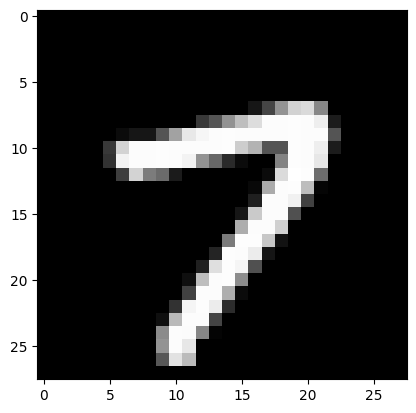

In [ ]:
plt.imshow(xtrain[505], cmap='gray')

In [ ]:
xtrain.shape

(60000, 28, 28)

In [ ]:
print(xtrain.reshape(60000,-1).max(), xtrain.reshape(60000,-1).min())

255 0


In [ ]:
xtrain_std = xtrain.reshape(xtrain.shape[0], -1) / 255.0
xtest_std = xtest.reshape(xtest.shape[0], -1) / 255.0

ytrain_onehot = to_categorical(ytrain)
ytest_onehot = to_categorical(ytest)

In [ ]:
np.unique(ytrain)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
model = Sequential()

model.add(Input(shape=(xtrain_std.shape[1], )))

model.add(Dense(xtrain_std.shape[1], activation='relu'))

model.add(Dense(256, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818,970 (3.12 MB)

 Trainable params: 818,970 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
res = model.fit(xtrain_std, ytrain_onehot, epochs=3, validation_data=(xtest_std, ytest_onehot))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9459 - loss: 0.1798 - val_accuracy: 0.9688 - val_loss: 0.0986
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9758 - loss: 0.0772 - val_accuracy: 0.9723 - val_loss: 0.0809
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9827 - loss: 0.0536 - val_accuracy: 0.9783 - val_loss: 0.0720


Text(0.5, 1.0, 'Accuracy')

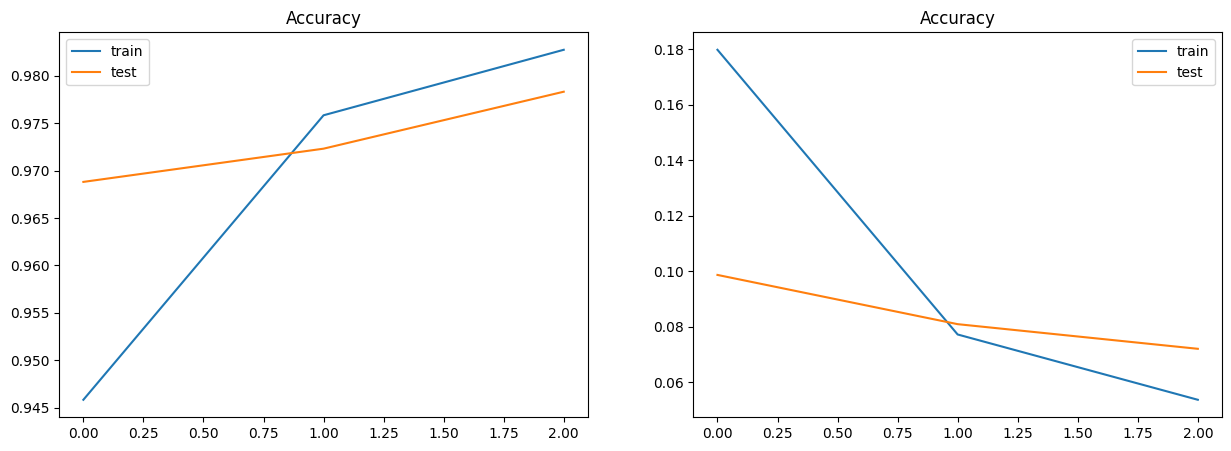

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(res.history['accuracy'])
plt.plot(res.history['val_accuracy'])
plt.legend(['train', 'test'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(res.history['loss'])
plt.plot(res.history['val_loss'])
plt.legend(['train', 'test'])
plt.title('Accuracy')

In [ ]:
model.save('mnist_model.h5')